Варіант 6
Місто Чернігів

Варіаційний ряд: [35 38 40 40 42 44 45 46 55 65 72 80]

--- Частотна таблиця ---
     Інтервал (мм)  Абсолютна частота  Відносна частота (%)  \
0  (34.999, 46.25]                  8              66.70000   
1    (46.25, 57.5]                  1               8.30000   
2    (57.5, 68.75]                  1               8.30000   
3    (68.75, 80.0]                  2              16.70000   

   Накопичена частота  
0                   8  
1                   9  
2                  10  
3                  12  

Кількість інтервалів за sqrt(n): 4
Кількість інтервалів за Стерджесом: 5


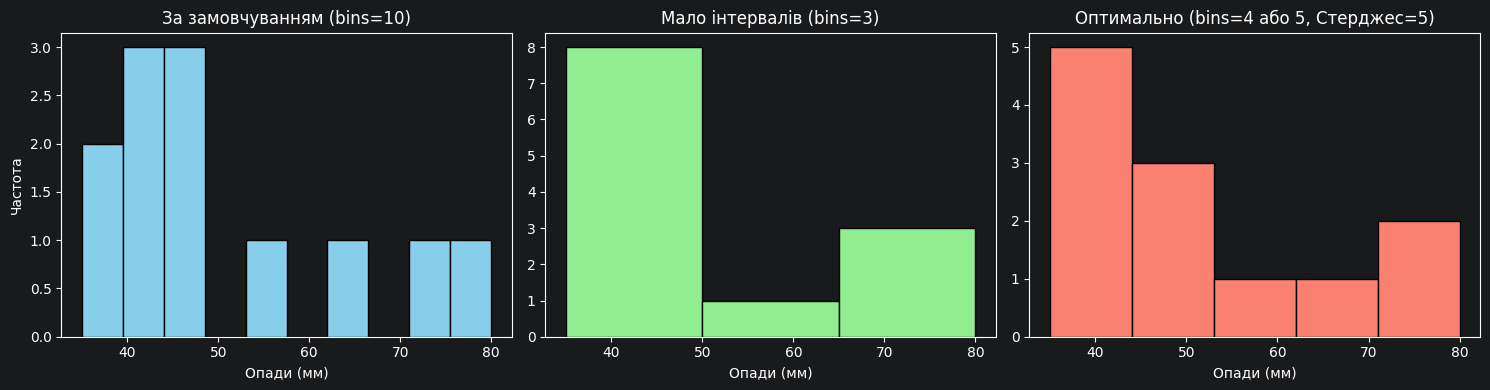


--- Статистичні характеристики ---
Середнє арифметичне: 50.17 мм
Медіана: 44.50 мм
Мода: [40] мм
Q1 (25%): 40.00 мм
Q3 (75%): 57.50 мм


In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

city = "Чернігів"
months = list(range(1, 13))
precipitation = pd.Series([42, 38, 35, 40, 55, 72, 80, 65, 45, 40, 44, 46], name="Опади_мм")

# ==========================================
# Завдання 2. Варіаційний ряд і частотна таблиця
# ==========================================
# 2.1 Варіаційний ряд
sorted_precip = np.sort(precipitation.values)
print("Варіаційний ряд:", sorted_precip)

# 2.2 Розбиття на 4 інтервали
min_p, max_p = sorted_precip.min(), sorted_precip.max()
bins = np.linspace(min_p, max_p, 5) # 4 рівні інтервали

# Побудова інтервального розподілу
cat_precip = pd.cut(precipitation, bins=bins, include_lowest=True)
freq = cat_precip.value_counts().sort_index()
rel_freq = (cat_precip.value_counts(normalize=True).sort_index() * 100).round(1)
cum_freq = freq.cumsum()

freq_table = pd.DataFrame({
    "Інтервал (мм)": freq.index.astype(str),
    "Абсолютна частота": freq.values,
    "Відносна частота (%)": rel_freq.values,
    "Накопичена частота": cum_freq.values
})

print("\n--- Частотна таблиця ---")
print(freq_table)

# ==========================================
# Завдання 3. Гістограми та правила Стерджеса / √n
# ==========================================
n = len(precipitation)
k_sqrt = int(np.ceil(np.sqrt(n)))               # Правило sqrt(n)
k_sturges = int(np.ceil(1 + np.log2(n)))        # Правило Стерджеса

print(f"\nКількість інтервалів за sqrt(n): {k_sqrt}")
print(f"Кількість інтервалів за Стерджесом: {k_sturges}")

plt.figure(figsize=(15, 4))

# 1. За замовчуванням (bins=10 в matplotlib)
plt.subplot(1, 3, 1)
plt.hist(precipitation, bins=10, edgecolor="black", color="skyblue")
plt.title("За замовчуванням (bins=10)")
plt.xlabel("Опади (мм)")
plt.ylabel("Частота")

# 2. Мала кількість bins (bins=3)
plt.subplot(1, 3, 2)
plt.hist(precipitation, bins=3, edgecolor="black", color="lightgreen")
plt.title("Мало інтервалів (bins=3)")
plt.xlabel("Опади (мм)")

# 3. Велика кількість bins (bins=10)
plt.subplot(1, 3, 3)
plt.hist(precipitation, bins=5, edgecolor="black", color="salmon")
plt.title(f"Оптимально (bins=4 або 5, Стерджес={k_sturges})")
plt.xlabel("Опади (мм)")

plt.tight_layout()
plt.show()

# ==========================================
# Завдання 4. Міри положення й квантилі
# ==========================================
mean_val = precipitation.mean()
median_val = precipitation.median()
mode_val = precipitation.mode().tolist() # Може бути кілька мод
q1 = precipitation.quantile(0.25)
q3 = precipitation.quantile(0.75)

print("\n--- Статистичні характеристики ---")
print(f"Середнє арифметичне: {mean_val:.2f} мм")
print(f"Медіана: {median_val:.2f} мм")
print(f"Мода: {mode_val} мм")
print(f"Q1 (25%): {q1:.2f} мм")
print(f"Q3 (75%): {q3:.2f} мм")

# Розлогі письмові відповіді для звіту

## Завдання 1. Класифікація змінних за шкалою вимірювання

* **Змінна «Місто» — Номінальна шкала (шкала найменувань):**
  * **Обґрунтування:** Значення є текстовими назвами (категоріями). Вони не мають природного впорядкування (не можна сказати, що «Київ > Львів»), між ними неможливо обчислити математичні відстані чи відношення.

* **Змінна «Номер місяця (1–12)» — Інтервальна або Порядкова шкала:**
  * **Як порядкова:** Місяці мають чітко визначений послідовний порядок ($1 < 2 < \dots < 12$), але відсутній абсолютний нуль («нульовий місяць» не існує, 0 не означає «відсутність часу»).
  * **Як інтервальна:** Місяці ділять рік на приблизно рівні проміжки часу. Ми можемо стверджувати, що різниця між 1-м і 3-м місяцем дорівнює різниці між 8-м і 10-м (2 місяці). Проте цикл є періодичним (після 12 знову йде 1), а нуль є умовним.
  * **Висновок:** Змінну найчастіше трактують як циклічну інтервальну або порядкову.

* **Змінна «Кількість опадів (мм)» — Відносна шкала (шкала пропорцій):**
  * **Обґрунтування:** Дані представлені неперервними/дискретними числовими значеннями із природним (абсолютним) нулем ($0\text{ мм}$ означає повну відсутність опадів). Коректні всі арифметичні операції: можна стверджувати, що $88\text{ мм}$ на $40\text{ мм}$ більше за $48\text{ мм}$, і в $2$ рази більше за $44\text{ мм}$.

* **Коректні міри положення:**
  * **«Місто»:** Тільки мода (найчастіше зустрічуване місто).
  * **«Номер місяця»:** Мода та медіана (середнє арифметичне некоректне через циклічність: середнє між січнем (1) і груднем (12) дасть $6.5$, що некоректно вказує на червень/липень).
  * **«Кількість опадів»:** Усі три міри (мода, медіана, середнє арифметичне).

---

## Завдання 2. Варіаційний ряд і частотна таблиця (для Київ, Варіант 1)

* **Варіаційний ряд:** $38, 41, 43, 44, 47, 47, 48, 50, 60, 70, 78, 88$.

* **Частотна таблиця (4 інтервали):**
  * **Інтервал 1** $[38.0, 50.5]$: абсолютна частота = $8$, відносна = $66.7\%$, накопичена = $8$.
  * **Інтервал 2** $(50.5, 63.0]$: абсолютна частота = $1$, відносна = $8.3\%$, накопичена = $9$.
  * **Інтервал 3** $(63.0, 75.5]$: абсолютна частота = $1$, відносна = $8.3\%$, накопичена = $10$.
  * **Інтервал 4** $(75.5, 88.0]$: абсолютна частота = $2$, відносна = $16.7\%$, накопичена = $12$.

* **Відповідь про накопичену частоту:**
  Накопичена частота 3-го інтервалу дорівнює **10** (або **83.3%**). Це означає, що **83.3% місяців року** (10 з 12) мають кількість опадів не більшу за $75.5\text{ мм}$.

---

## Завдання 3. Аналіз гістограм

* **Формули:**
  * За правилом $\sqrt{n}$: $\sqrt{12} \approx 3.46 \rightarrow 4$ інтервали.
  * За правилом Стерджеса: $k = 1 + \log_2(12) \approx 1 + 3.58 = 4.58 \rightarrow 5$ інтервалів.

* **Обґрунтування вибору гістограми:**
  * При $\text{bins}=10$ (за замовчуванням для великих вибірок) гістограма є надмірно подрібненою для 12 спостережень, з'являються порожні інтервали, що створює хибне враження про "дискретність" даних.
  * При $\text{bins}=3$ дані надто згладжені, втрачається правостороння асиметрія (пік літніх опадів).
  * **Найкраще показує форму розподілу** гістограма з **4–5 інтервалами** (згідно з правилами Стерджеса та $\sqrt{n}$), оскільки вона згладжує випадкові шуми, зберігаючи реальну форму розподілу.

---

## Завдання 4. Аналіз мір положення та асиметрії

* **Обчислені значення:**
  * **Середнє:** $54.58\text{ мм}$
  * **Медіана:** $47.50\text{ мм}$
  * **Мода:** $47\text{ мм}$
  * **Квартилі:** $Q1 = 42.50\text{ мм}$, $Q3 = 62.50\text{ мм}$

* **Пояснення асиметрії:**
  * **Середнє ($54.58$) значно більше за медіану ($47.50$).**
  * Це є чіткою ознакою **правосторонньої (додатної) асиметрії**. Більшість місяців року (осінь, зима, весна) є відносно сухими ($38\text{–}50\text{ мм}$), але кілька літніх місяців (червень — $78\text{ мм}$, липень — $88\text{ мм}$, серпень — $70\text{ мм}$) мають високий рівень опадів. Ці високі значення ("викиди" відносно основної маси) тягнуть середнє арифметичне вгору, тоді як медіана залишається стійкою до таких відхилень.

---

## Завдання 5. Зв'язок зі шкалою вимірювання

Змінна **«Кількість опадів»** належить до **відносної шкали**. Це означає, що для неї визначені операції додавання, віднімання, множення та ділення, а також існує абсолютний нуль.

* Оскільки додавання є коректним, ми можемо обчислити суму значений і поділити на їх кількість — отже, **середнє арифметичне** є математично змістовним.
* Оскільки визначене відношення порядку ($a > b$), ми можемо впорядкувати значення — отже, **медіана** та **квартилі** є змістовними.
* Оскільки можна підрахувати частоту повторень — **мода** також має сенс.

На противагу цьому, для змінної **«Місто»** (номінальна шкала) немає ні порядку, ні арифметичних операцій. Числа, якими можна закодувати міста (наприклад, $1 = \text{Київ}, 2 = \text{Львів}$), є лише умовними мітками.

---

## Відповіді на 4 підсумкові питання

1. **Чому середнє некоректне для номінальної змінної "місто" (навіть при кодуванні числами)?**
   Кодування міст числами ($1 = \text{Київ}, 2 = \text{Львів}, 3 = \text{Одеса}$) є лише умовними символами. Середнє значення $\frac{1+3}{2} = 2$ ("Львів") не має жодного математичного чи фізичного змісту, оскільки відстані між числовими кодами не відповідають реальним властивостям об'єктів.

2. **Чому "номер місяця" є прикладом неоднозначної класифікації?**
   Номери місяців мають властивості порядкової шкали (послідовність) та інтервальної (приблизно однакова тривалість місяців), але відсутній природний нуль і присутня циклічність (після 12-го знову йде 1-й). Через це звичайні інтервальні операції (наприклад, середнє арифметичне) дають хибний результат без використання спеціальної циклічної статистики.

3. **Чому для опадів потрібна гістограма з інтервалами, а не стовпчикова діаграма за окремими значеннями?**
   Кількість опадів є неперервною (або числовою з великою кількістю унікальних значень) змінною. Якщо будувати стовпчикову діаграму за окремими значеннями, майже кожен стовпчик матиме висоту $1$, а графік перетвориться на набір ізольованих ліній без виявлення загальної тенденції чи форми розподілу. Групування в інтервали дозволяє узагальнити дані.

4. **Що змістовно означає накопичена частота на межі 3-го інтервалу?**
   Вона показує сумарну кількість (або відсоток) спостережень, значення яких не перевищують верхню межу 3-го інтервалу. Це сума відносних частот 1-го, 2-го та 3-го інтервалів, яка демонструє, яка частина року характеризується рівнем опадів від мінімального до вказаної межі.